# 02 — Training

Overview of the training setup and results for all experiments:
- **Mel-CNN** — main model, mel-spectrogram input, SpecAugment + Dropout
- **MFCC-CNN** — same architecture with MFCC input
- **Mel-CNN (no SpecAugment)** — ablation: disable SpecAugment
- **Mel-CNN (no Dropout)** — ablation: disable all dropout
- **RAVDESS from scratch** — same model trained on RAVDESS only
- **RAVDESS transfer** — fine-tuned from CREMA-D weights (lr=0.0003)

## How to Train

Run from the project root (all with `--seed 42` for reproducibility):

```bash
# Core experiments
python train.py --feature mel --seed 42                   # Full model (mel)
python train.py --feature mfcc --seed 42                  # MFCC ablation
python train.py --feature mel --no-augment --seed 42      # No SpecAugment
python train.py --feature mel --no-dropout --seed 42      # No Dropout

# Cross-dataset: RAVDESS from scratch
python train.py --feature mel --dataset ravdess --seed 42

# Transfer learning: CREMA-D → RAVDESS (full fine-tune, lr=0.0003)
python train.py --feature mel --dataset ravdess --pretrain-from models/mel_best_model.pt --lr 0.0001 --seed 42
```

Models are saved to `models/`, results to `results/{experiment}/`.

## Training Configuration

| Parameter | Value |
|-----------|-------|
| Optimizer | AdamW (lr=0.001, weight_decay=1e-4) |
| Scheduler | CosineAnnealingLR (T_max=100, eta_min=1e-6) |
| Loss | CrossEntropyLoss (label_smoothing=0.1) |
| Max epochs | 100 |
| Early stopping | patience=25 (macro-F1) |
| Batch size | 32 |
| Augmentation | SpecAugment (p=0.7) + Mixup (α=0.4) |
| Data split | 70% train / 15% val / 15% test (speaker-independent) |

In [1]:
import sys
sys.path.insert(0, '..')

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Loss Curves

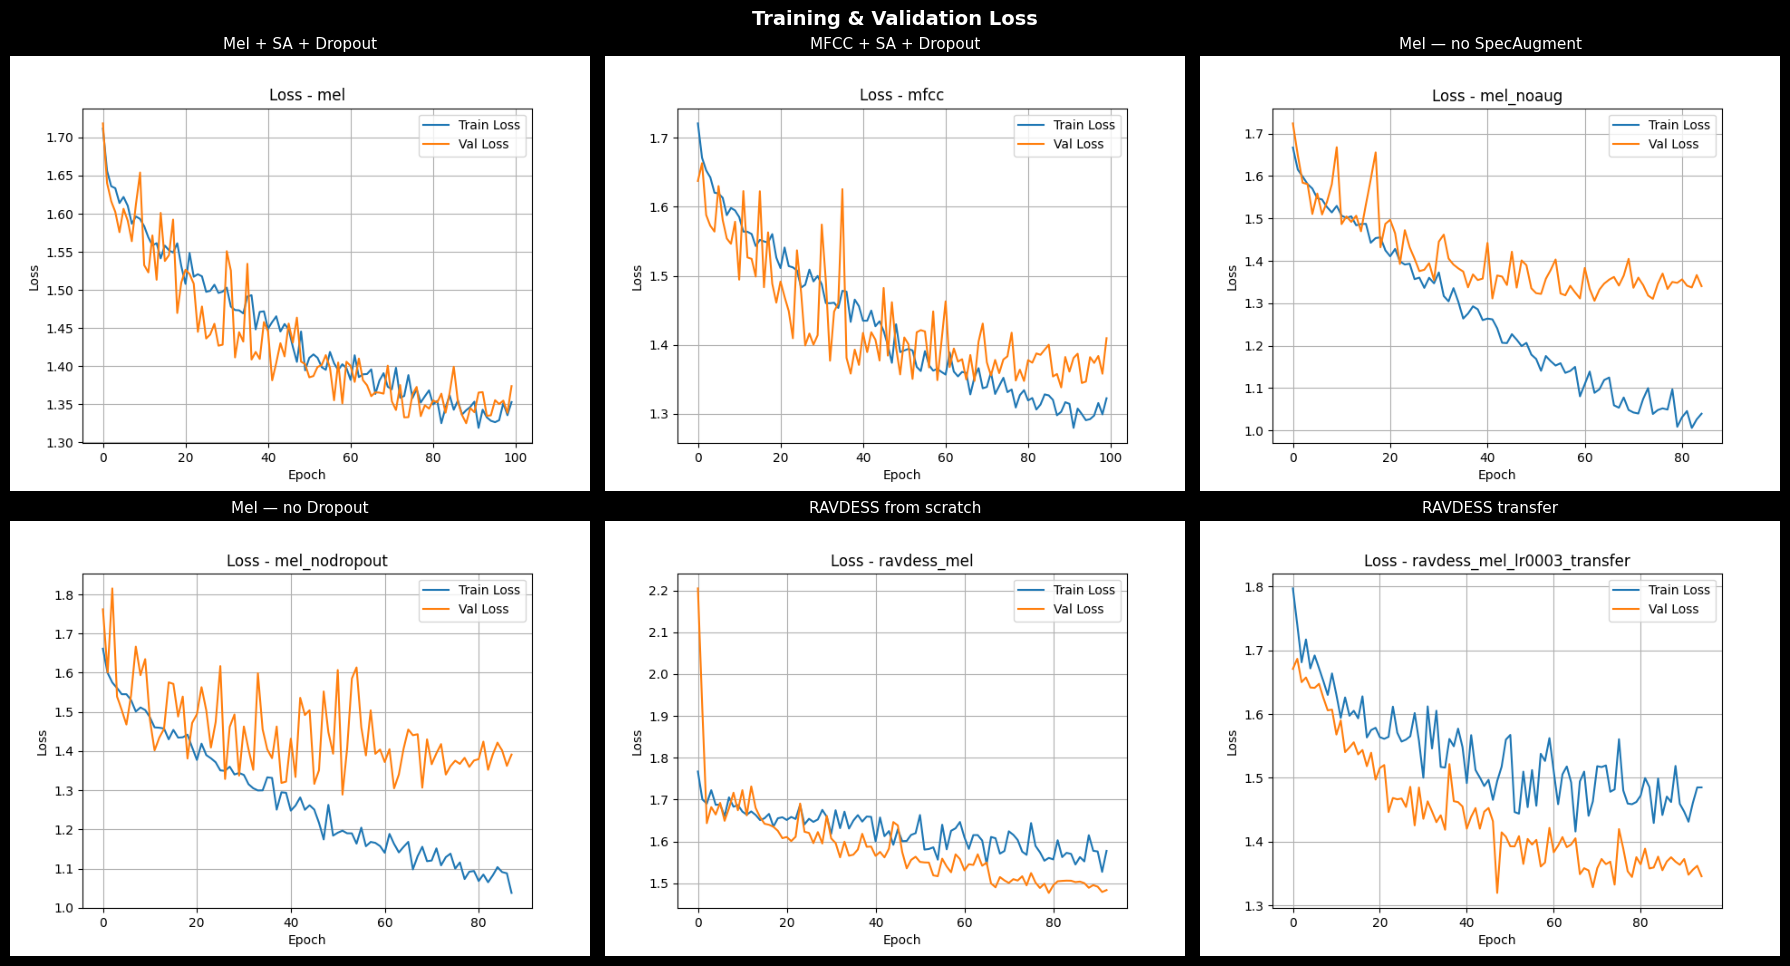

In [2]:
experiments = [
    ('mel',                        '../results/mel/mel_loss.png',                                       'Mel + SA + Dropout'),
    ('mfcc',                       '../results/mfcc/mfcc_loss.png',                                     'MFCC + SA + Dropout'),
    ('mel_noaug',                  '../results/mel_noaug/mel_noaug_loss.png',                            'Mel — no SpecAugment'),
    ('mel_nodropout',              '../results/mel_nodropout/mel_nodropout_loss.png',                    'Mel — no Dropout'),
    ('ravdess_mel',                '../results/ravdess_mel/ravdess_mel_loss.png',                        'RAVDESS from scratch'),
    ('ravdess_mel_lr0003_transfer','../results/ravdess_mel_lr0003_transfer/ravdess_mel_lr0003_transfer_loss.png', 'RAVDESS transfer'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (_, path, title) in zip(axes, experiments):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{path}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## F1 Score Curves

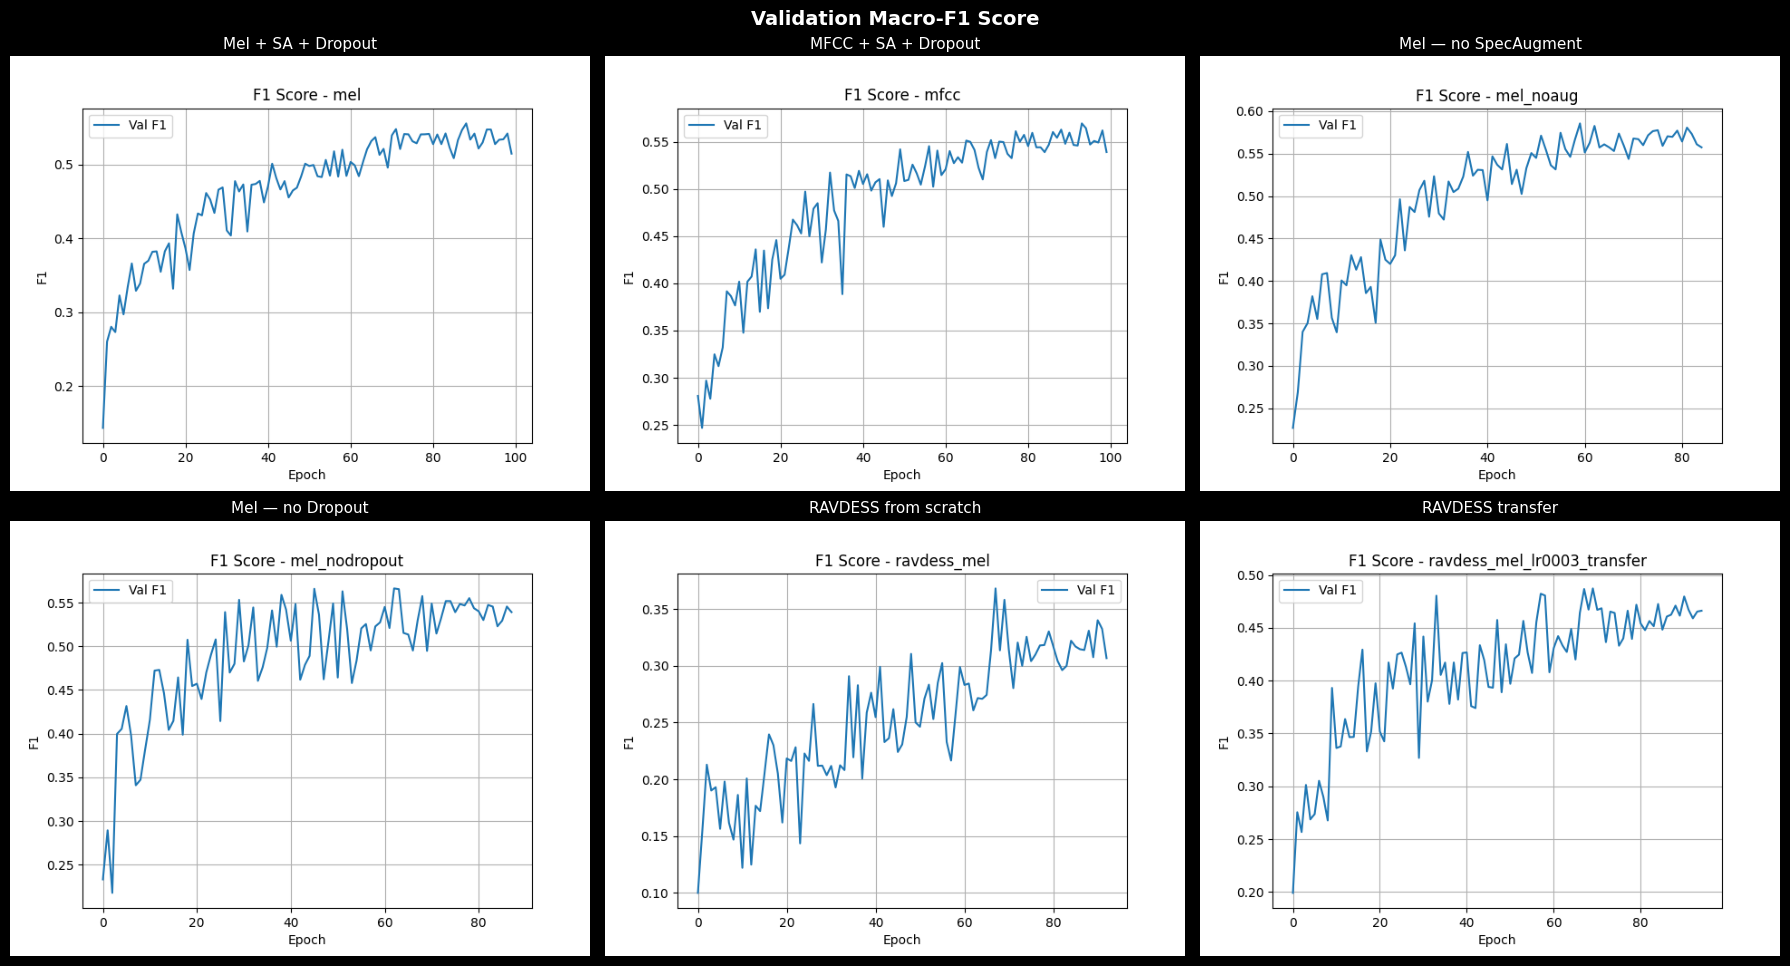

In [3]:
experiments_f1 = [
    ('mel',                        '../results/mel/mel_F1score.png',                                       'Mel + SA + Dropout'),
    ('mfcc',                       '../results/mfcc/mfcc_F1score.png',                                     'MFCC + SA + Dropout'),
    ('mel_noaug',                  '../results/mel_noaug/mel_noaug_F1score.png',                            'Mel — no SpecAugment'),
    ('mel_nodropout',              '../results/mel_nodropout/mel_nodropout_F1score.png',                    'Mel — no Dropout'),
    ('ravdess_mel',                '../results/ravdess_mel/ravdess_mel_F1score.png',                        'RAVDESS from scratch'),
    ('ravdess_mel_lr0003_transfer','../results/ravdess_mel_lr0003_transfer/ravdess_mel_lr0003_transfer_F1score.png', 'RAVDESS transfer'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (_, path, title) in zip(axes, experiments_f1):
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'Not found:\n{path}', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
plt.suptitle('Validation Macro-F1 Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Results Comparison Table(after evaluation.ipynb) literally the same

Fill in the best macro-F1 values from the terminal output of each training run.

In [5]:
import pandas as pd

df = pd.read_csv('../results/comparison_table.csv')

# Display only the columns relevant to training comparison
display_cols = ['experiment', 'dataset', 'feature', 'augment', 'dropout', 'clean_f1']
display(df[display_cols].rename(columns={
    'experiment': 'Experiment',
    'dataset':    'Dataset',
    'feature':    'Feature',
    'augment':    'SpecAugment',
    'dropout':    'Dropout',
    'clean_f1':   'Clean F1 (weighted)',
}))

,Experiment,Dataset,Feature,SpecAugment,Dropout,Clean F1 (weighted)
0,mel,crema,mel,True,True,0.6162
1,mfcc,crema,mfcc,True,True,0.6436
2,mel_noaug,crema,mel,False,True,0.6345
3,mel_nodropout,crema,mel,True,False,0.6244
4,ravdess_mel,ravdess,mel,True,True,0.3930
5,ravdess_mel_lr0003_transfer,ravdess,mel,True,True,0.5268
